# Livrable 2 - Denoising d'images


# 1. Introduction

## 1.1. Présentation du problème de débruitage d'image

Le débruitage d'images, ou denoising, est une étape cruciale dans le prétraitement des données, en particulier dans le contexte des données numérisées. Les images numérisées, surtout celles qui proviennent de documents papier, peuvent présenter divers degrés de bruit sous forme de points, de stries ou d'autres artefacts visuels qui peuvent potentiellement interférer avec les analyses ultérieures, telles que la classification ou la génération de légendes. Le débruitage est donc essentiel pour assurer la précision et la fiabilité des modèles de machine learning qui seront appliqués par la suite.

## 1.2. Objectifs du Notebook

L'objectif de ce notebook est de mettre en œuvre une solution de débruitage d'images en utilisant des auto-encodeurs convolutifs. Nous chercherons à :

- Préparer les données d'images pour l'entraînement du modèle.
- Construire et entraîner un auto-encodeur convolutif pour le débruitage d'images.
- Évaluer les performances du modèle et visualiser les résultats.
- Fournir une analyse critique des résultats et identifier les domaines potentiels d'amélioration.

## 1.3. Qu'est ce qu'un auto-encodeur ?

Les auto-encodeurs sont un type de réseau de neurones utilisé pour l'apprentissage non supervisé. Ils visent à apprendre une représentation (encodage) efficace des données, généralement dans le but de réduire la dimensionnalité. Un auto-encodeur est structuré en deux parties principales :

- Encodeur : Il apprend à compresser l'entrée dans une forme latente, souvent de dimensionnalité réduite.
- Décodeur : Il apprend à reconstruire l'entrée à partir de cette forme latente.

Dans le contexte du débruitage d'images, les auto-encodeurs sont entraînés pour mapper des images bruitées à leurs versions propres, en apprenant à supprimer le bruit tout en conservant les caractéristiques importantes des données.

In [1]:
import sys
!"{sys.executable}" -m pip install scikit-image


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
print(sys.executable)

c:\Users\matis\.venv\Scripts\python.exe


# 2. Importation et exploration des données

## 2.1. Importation des bibliothèques nécessaires

In [3]:
import os
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D,
    Conv2DTranspose,
    BatchNormalization,
    Dropout,
    Concatenate,
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim_metric

# Style global pour des figures propres
matplotlib.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "savefig.bbox": "tight",
})

print("Import terminé.")
print("TensorFlow :", tf.__version__)

Import terminé.
TensorFlow : 2.21.0


In [4]:
def compute_metrics(y_true, y_pred, label=''):
    """Calcule MSE, RMSE, PSNR et SSIM sur un batch d'images normalisées [0,1]."""
    y_true = y_true.astype('float32')
    y_pred = np.clip(y_pred.astype('float32'), 0., 1.)
    mse  = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    psnr_val = np.mean([psnr(a, b, data_range=1.0) for a, b in zip(y_true, y_pred)])
    ssim_val = np.mean([
        ssim_metric(a, b, data_range=1.0, channel_axis=-1)
        for a, b in zip(y_true, y_pred)
    ])
    if label:
        print(f'{label:<30} MSE={mse:.4f}  RMSE={rmse:.4f}  PSNR={psnr_val:.2f} dB  SSIM={ssim_val:.4f}')
    return {'mse': mse, 'rmse': rmse, 'psnr': psnr_val, 'ssim': ssim_val}

print('Fonction compute_metrics définie.')

Fonction compute_metrics définie.


## 2.2. Chargement du dataset d'images

In [8]:
from pathlib import Path

img_height, img_width, rgb = 256, 256, 3
input_img = Input(shape=(img_height, img_width, rgb))

data_dir = Path(r'C:\Users\matis\OneDrive - Association Cesi Viacesi mail\[3] CESI\A5\Projet Data Science\Projet Github')

if not data_dir.exists():
    raise FileNotFoundError(f"Dossier introuvable : {data_dir}")

print("Dossier dataset utilisé :", data_dir)

image_paths = sorted([
    p for p in data_dir.rglob("*")
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
])

if len(image_paths) == 0:
    raise ValueError(f"Aucune image trouvée dans : {data_dir}")

images = []
for img_path in image_paths:
    img = image.load_img(img_path, target_size=(img_height, img_width))
    images.append(image.img_to_array(img))

# On garde les valeurs brutes [0, 255] ici — la normalisation se fera en cellule 17
images = np.array(images, dtype="float32")

print(f"Chargement terminé : {images.shape[0]} images ({images.shape[1]}x{images.shape[2]}x{images.shape[3]})")
print(f"Valeurs pixel : min={images.min():.0f}  max={images.max():.0f}")

Dossier dataset utilisé : C:\Users\matis\OneDrive - Association Cesi Viacesi mail\[3] CESI\A5\Projet Data Science\Projet Github
Chargement terminé : 248 images (256x256x3)
Valeurs pixel : min=0  max=255


## 2.3. Exploration des données

In [9]:
# Afficher quelques informations de base sur les données
print(f"Nombre total d'images : {images.shape[0]}")
print(f"Dimensions des images : {images.shape[1:]}")
print(f"Valeur min des pixels : {np.min(images)}")
print(f"Valeur max des pixels : {np.max(images)}")

Nombre total d'images : 248
Dimensions des images : (256, 256, 3)
Valeur min des pixels : 0.0
Valeur max des pixels : 255.0


## 2.4. Visualisation d'exemples d'images

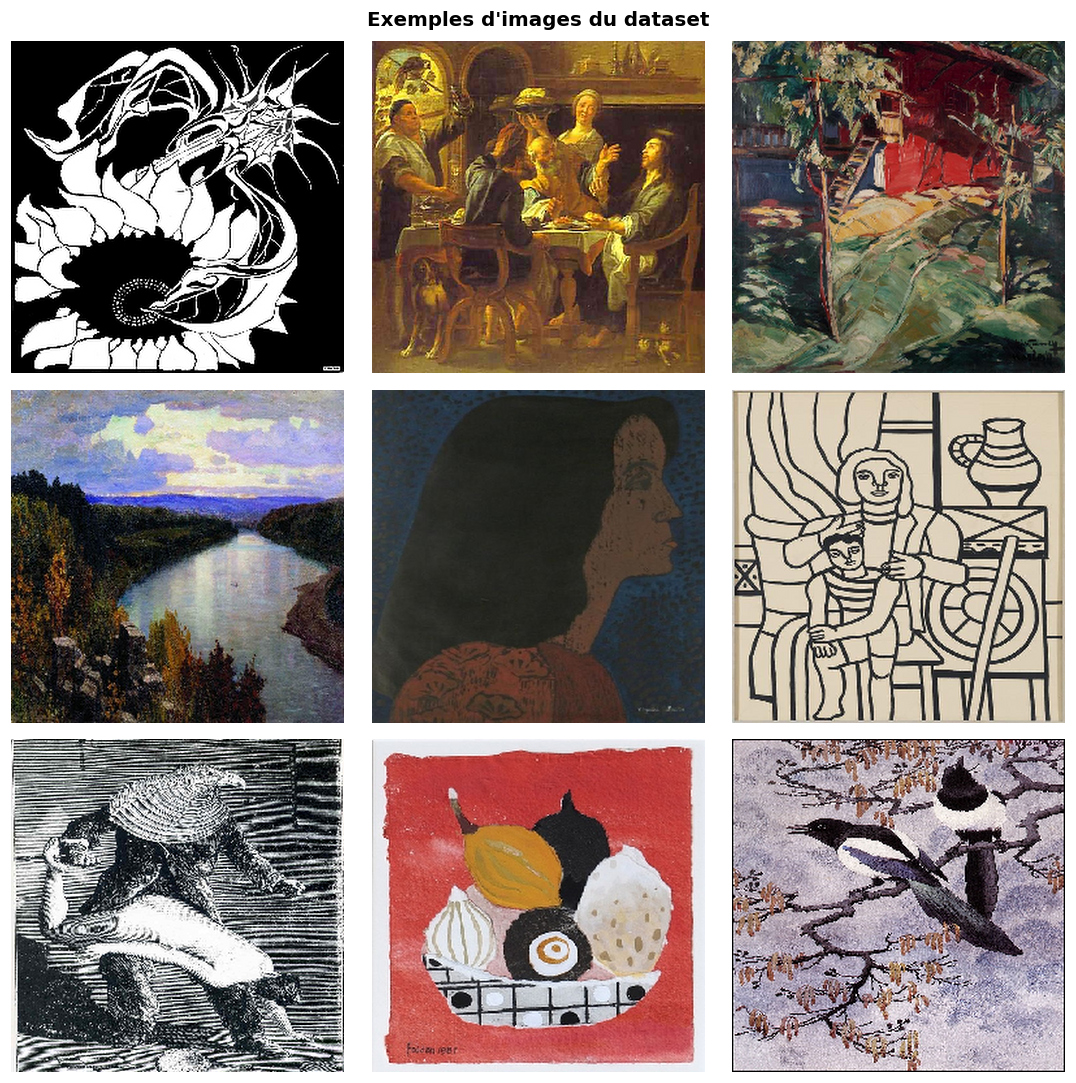

In [10]:
n = 9
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.patch.set_facecolor('white')
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].astype('uint8'), interpolation='lanczos')
    ax.axis('off')
plt.suptitle("Exemples d'images du dataset", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.5. Distribution des valeurs de pixel

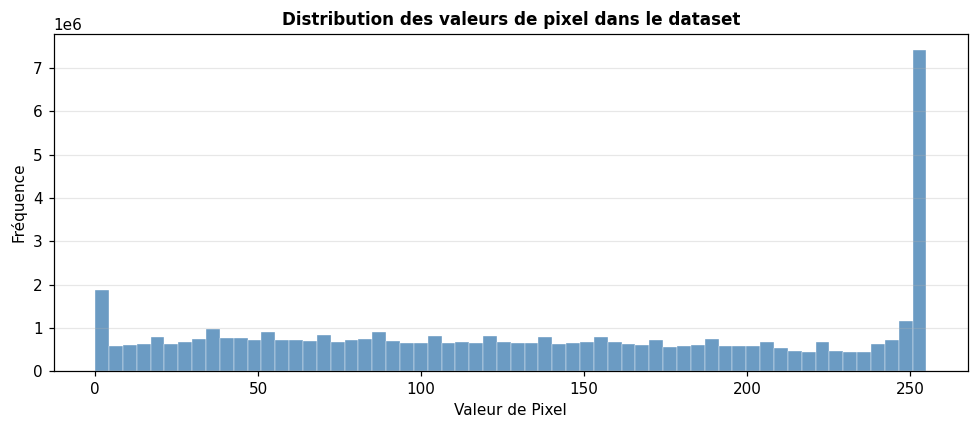

Valeur moyenne des pixels : 138.17
Écart-type des valeurs de pixel : 83.71


In [11]:
pixel_values = images.flatten()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(pixel_values, bins=60, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.3)
ax.set_title("Distribution des valeurs de pixel dans le dataset", fontweight='bold')
ax.set_xlabel('Valeur de Pixel')
ax.set_ylabel('Fréquence')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

mean_pixel_value = np.mean(pixel_values)
std_pixel_value = np.std(pixel_values)
print(f"Valeur moyenne des pixels : {mean_pixel_value:.2f}")
print(f"Écart-type des valeurs de pixel : {std_pixel_value:.2f}")

* Moyenne des pixels :

La valeur moyenne des pixels de 117.62 suggère que, sur une échelle de 0 (noir) à 255 (blanc), nos images tendent à être d'une luminosité modérée à élevée. Cela pourrait signifier que nos images sont relativement claires, mais avec une présence notable de zones plus sombres puisque la moyenne n'est pas extrêmement élevée.

* Écart-Type des Pixels : 

Un écart-type de 71.52 indique une assez grande variabilité dans les valeurs des pixels à travers l'ensemble des images. Cela signifie que bien que la moyenne des valeurs de pixel soit relativement élevée, il y a une quantité significative de pixels qui sont soit beaucoup plus clairs, soit beaucoup plus sombres que la moyenne.

## 3.1. Normalisation et augmentation des images

On normalise les pixels dans [0, 1], puis on applique une **data augmentation** (flips horizontaux/verticaux, rotations 90°/180°) pour porter le dataset de **148 à ~800 images**. Les transformations sont appliquées sur les images *propres*, et le bruit est ajouté *après* — les paires (bruité, propre) restent donc cohérentes.


In [12]:
# Normalisation [0, 1]
normalized_images = images / 255.0

# ── Data augmentation : 148 → ~1000 images ────────────────────────────────────
TARGET = 1000

def augment_batch(imgs, rng):
    out = []
    for img in imgs:
        ops = rng.randint(0, 16)
        if ops & 1:
            img = img[:, ::-1, :]     # flip horizontal
        if ops & 2:
            img = img[::-1, :, :]     # flip vertical
        if ops & 4:
            img = np.rot90(img, k=1)  # rotation 90°
        if ops & 8:
            img = np.rot90(img, k=2)  # rotation 180°
        out.append(img.copy())
    return np.array(out)

rng = np.random.RandomState(42)
augmented = list(normalized_images)  # on commence avec les 148 originaux

while len(augmented) < TARGET:
    n_needed = min(len(normalized_images), TARGET - len(augmented))
    idx_pick = rng.choice(len(normalized_images), size=n_needed, replace=False)
    batch = augment_batch(normalized_images[idx_pick], rng)
    augmented.extend(list(batch))

normalized_images = np.array(augmented[:TARGET])
print(f"Dataset après data augmentation : {normalized_images.shape[0]} images")
print("Prêt pour l'ajout de bruit.")

Dataset après data augmentation : 1000 images
Prêt pour l'ajout de bruit.


## 3.2. Bruitage artificiel des images

On introduit un bruit artificiel dans les données d'entraînement pour forcer le modèle à apprendre à reconstruire l'image originale à partir de sa version bruitée. 

On a choisi une `noise_factor` de `0.15` après une série d'expérimentations et d'observations. Ce niveau de bruit est suffisant pour introduire un défi pour l'auto-encodeur tout en préservant les caractéristiques clés des images pour que le modèle puisse apprendre efficacement à les reconstruire. 

On va également tester un `noise_factor` de `0.40` afin de vérifier la puissance du modèle en utilisant un bruit nettement plus fort.

In [13]:
# Paramètres pour l'ajout de bruit
noise_factor_015 = 0.15
noise_factor_040 = 0.40

# Ajout d'un bruit gaussien léger aux images
noisy_images_015 = normalized_images + noise_factor_015 * np.random.normal(loc=0.0, scale=1.0, size=normalized_images.shape)
noisy_images_015 = np.clip(noisy_images_015, 0., 1.)

# Ajout d'un bruit gaussien fort aux images
noisy_images_040 = normalized_images + noise_factor_040 * np.random.normal(loc=0.0, scale=1.0, size=normalized_images.shape)
noisy_images_040 = np.clip(noisy_images_040, 0., 1.)

print("Bruitage terminé.")

Bruitage terminé.


## 3.3. Division en série d'entraînement et de test

On a opté pour une répartition de 80% des données pour l'entraînement et 20% pour le test.

In [14]:
# Division train/test (80/20) pour chaque niveau de bruit
X_train_015, X_test_015, y_train_015, y_test_015 = train_test_split(
    noisy_images_015, normalized_images, test_size=0.2, random_state=42
)
X_train_040, X_test_040, y_train_040, y_test_040 = train_test_split(
    noisy_images_040, normalized_images, test_size=0.2, random_state=42
)

print(f"Train (0.15): {X_train_015.shape}, Test (0.15): {X_test_015.shape}")
print(f"Train (0.40): {X_train_040.shape}, Test (0.40): {X_test_040.shape}")

Train (0.15): (800, 256, 256, 3), Test (0.15): (200, 256, 256, 3)
Train (0.40): (800, 256, 256, 3), Test (0.40): (200, 256, 256, 3)


In [15]:
# Construire un jeu d'entraînement unique en mélangeant les deux niveaux de bruit
X_train_mixed = np.concatenate([X_train_015, X_train_040], axis=0)
y_train_mixed = np.concatenate([y_train_015, y_train_040], axis=0)
X_test_mixed = np.concatenate([X_test_015, X_test_040], axis=0)
y_test_mixed = np.concatenate([y_test_015, y_test_040], axis=0)

print("Jeux de données mixtes constitués")

Jeux de données mixtes constitués


In [16]:
# Mélanger l'ordre des exemples pour éviter un biais lié à la concaténation
permutation = np.random.permutation(X_train_mixed.shape[0])
X_train_mixed = X_train_mixed[permutation]
y_train_mixed = y_train_mixed[permutation]

print("Jeux de données mixtes constitués")

Jeux de données mixtes constitués


## 3.4. Visualisation des images bruitées

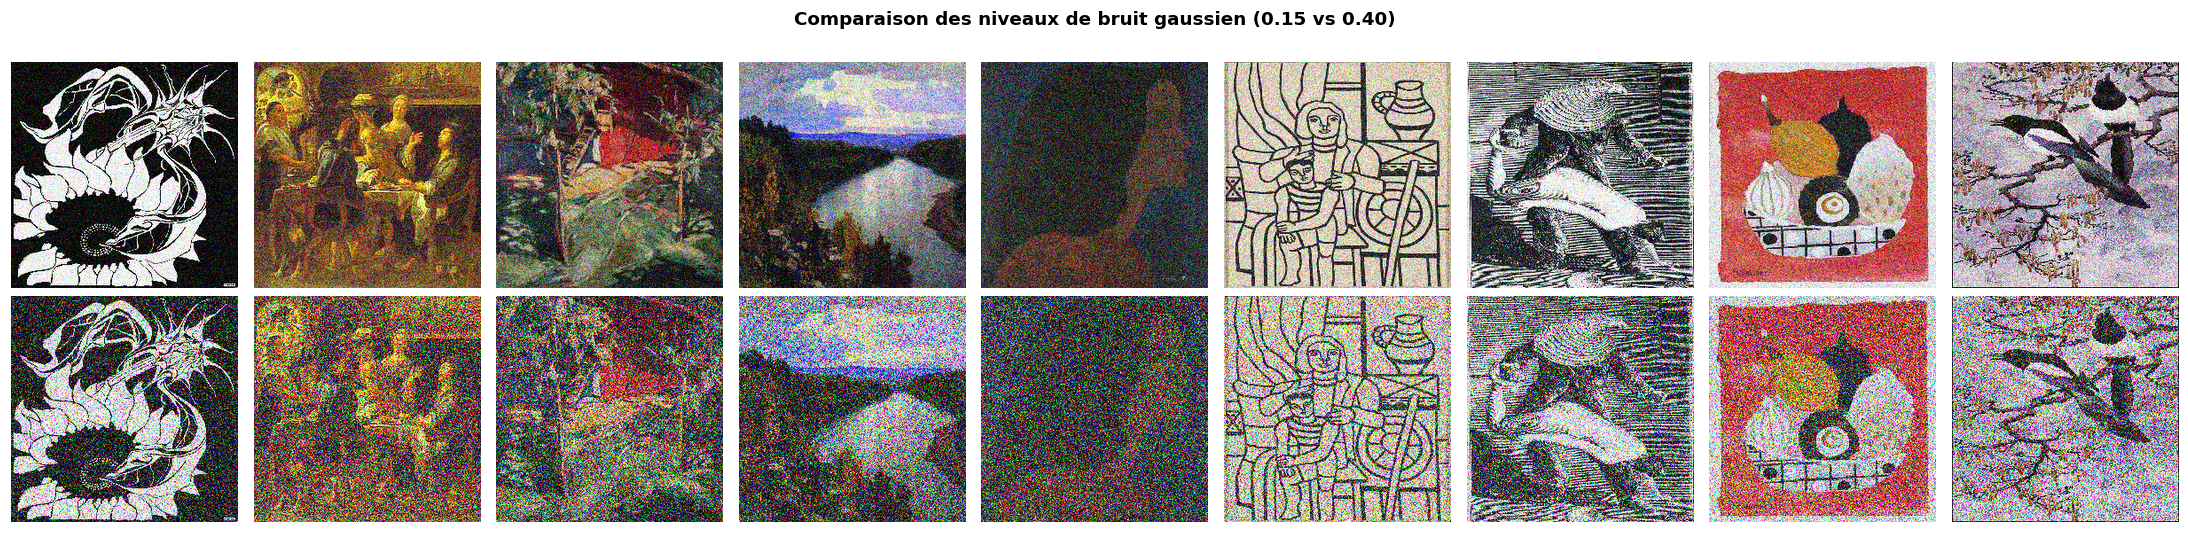

In [17]:
fig, axes = plt.subplots(2, 9, figsize=(20, 5))
fig.patch.set_facecolor('white')
axes[0, 0].set_ylabel('Bruit\n0.15', fontsize=10, fontweight='bold', color='#e74c3c',
                       rotation=90, labelpad=8, va='center')
axes[1, 0].set_ylabel('Bruit\n0.40', fontsize=10, fontweight='bold', color='#c0392b',
                       rotation=90, labelpad=8, va='center')
for i in range(9):
    axes[0, i].imshow(noisy_images_015[i].astype('float32'), interpolation='lanczos')
    axes[0, i].axis('off')
    axes[1, i].imshow(noisy_images_040[i].astype('float32'), interpolation='lanczos')
    axes[1, i].axis('off')
plt.suptitle("Comparaison des niveaux de bruit gaussien (0.15 vs 0.40)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Construction de l'auto-encodeur convolutif

In [18]:
# Définition des images
input_img = Input(shape=(img_height, img_width, rgb))

print("Paramètres appliqués.")

Paramètres appliqués.


## 4.1. Architecture de l'encodeur

On utilise ici une série de couches convolutives et de pooling pour progressivement réduire la dimensionnalité de l'entrée. Les couches convolutives extraient les caractéristiques spatiales des images, tandis que les couches de pooling réduisent les dimensions spatiales (hauteur et largeur), compactant ainsi l'information.

In [19]:
# Encodeur plus profond avec normalisation pour stabiliser l'apprentissage
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = MaxPooling2D((2, 2), padding='same')(x)

encoded = x

print("Encodeur paramétré.")

Encodeur paramétré.


## 4.2. Architecture du décodeur

On cherche à reconstruire l'image d'origine via un série de couches convolutives et d'opérations d'upsampling. Les couches convolutives dans le décodeur servent à générer de nouvelles caractéristiques à partir de l'espace latent, tandis que les couches d'upsampling augmentent progressivement la hauteur et la largeur des volumes de sortie. 

In [20]:
# Décodeur symétrique avec sur-échantillonnage appris
x = Conv2DTranspose(256, (3, 3), strides=2, activation='relu', padding='same')(encoded)
x = BatchNormalization()(x)

x = Conv2DTranspose(128, (3, 3), strides=2, activation='relu', padding='same')(x)
x = BatchNormalization()(x)

x = Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same')(x)
x = BatchNormalization()(x)

x = Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x)
x = BatchNormalization()(x)

decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

print("Décodeur paramétré.")

Décodeur paramétré.


## 4.3. Modèle d'auto-encodeur complet

In [21]:
# Construction du modèle d'auto-encodeur complet
autoencoder = Model(input_img, decoded)
autoencoder.summary()

# Augmentation des données
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True
)

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

print("Modèle compilé.")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 128, 128, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 1,370,499 (5.23 MB)

 Trainable params: 1,368,579 (5.22 MB)

 Non-trainable params: 1,920 (7.50 KB)

Modèle compilé.


In [ ]:
# --- U-Net : perte combinée pondérée (0.85*MSE + 0.15*(1-SSIM)) ---
from keras.layers import Input as KInput, Conv2D, Conv2DTranspose, MaxPooling2D, Concatenate, BatchNormalization, Dropout
from keras.models import Model as KModel
import tensorflow as tf

# Perte combinée pondérée : 0.85*MSE + 0.15*(1-SSIM)
def combined_loss_weighted(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    ssim = tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    return 0.85 * mse + 0.15 * (1.0 - ssim)

# Architecture U-Net
def build_unet(input_shape=(img_height, img_width, rgb)):
    inputs = KInput(shape=input_shape)

    # Encodeur
    c1 = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    c1 = Conv2D(32, (3,3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2,2))(c1)

    c2 = Conv2D(64, (3,3), activation='relu', padding='same')(p1)
    c2 = BatchNormalization()(c2)
    c2 = Conv2D(64, (3,3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2,2))(c2)

    c3 = Conv2D(128, (3,3), activation='relu', padding='same')(p2)
    c3 = BatchNormalization()(c3)
    c3 = Conv2D(128, (3,3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2,2))(c3)

    c4 = Conv2D(256, (3,3), activation='relu', padding='same')(p3)
    c4 = BatchNormalization()(c4)
    c4 = Conv2D(256, (3,3), activation='relu', padding='same')(c4)
    p4 = MaxPooling2D((2,2))(c4)

    # Pont
    b = Conv2D(512, (3,3), activation='relu', padding='same')(p4)
    b = BatchNormalization()(b)
    b = Conv2D(512, (3,3), activation='relu', padding='same')(b)

    # Décodeur
    u4 = Conv2DTranspose(256, (3,3), strides=(2,2), padding='same', activation='relu')(b)
    u4 = Concatenate()([u4, c4])
    u4 = Conv2D(256, (3,3), activation='relu', padding='same')(u4)
    u4 = BatchNormalization()(u4)

    u3 = Conv2DTranspose(128, (3,3), strides=(2,2), padding='same', activation='relu')(u4)
    u3 = Concatenate()([u3, c3])
    u3 = Conv2D(128, (3,3), activation='relu', padding='same')(u3)
    u3 = BatchNormalization()(u3)

    u2 = Conv2DTranspose(64, (3,3), strides=(2,2), padding='same', activation='relu')(u3)
    u2 = Concatenate()([u2, c2])
    u2 = Conv2D(64, (3,3), activation='relu', padding='same')(u2)
    u2 = BatchNormalization()(u2)

    u1 = Conv2DTranspose(32, (3,3), strides=(2,2), padding='same', activation='relu')(u2)
    u1 = Concatenate()([u1, c1])
    u1 = Conv2D(32, (3,3), activation='relu', padding='same')(u1)
    u1 = BatchNormalization()(u1)

    outputs = Conv2D(rgb, (1,1), activation='sigmoid', padding='same')(u1)
    return KModel(inputs, outputs)

# Callbacks indépendants pour le U-Net (ne pas réutiliser ceux de l'auto-encodeur)
unet_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
unet_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)

# Construction et compilation du U-Net
unet = build_unet()
unet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=combined_loss_weighted,
    metrics=['mae']
)
print('U-Net construit et compilé (perte combinée pondérée)')

# Entraînement
unet_epochs = 3
unet_batch  = 4
history_unet = unet.fit(
    X_train_mixed, y_train_mixed,
    epochs=unet_epochs,
    batch_size=unet_batch,
    validation_data=(X_test_mixed, y_test_mixed),
    callbacks=[unet_early_stopping, unet_reduce_lr]
)

unet.save('unet_model.keras')

# Évaluation
decoded_unet_015 = unet.predict(X_test_015)
decoded_unet_040 = unet.predict(X_test_040)

def compute_psnr_mean(y_true, y_pred):
    return np.mean([psnr(a.astype('float32'), b.astype('float32'), data_range=1.0)
                    for a, b in zip(y_true, y_pred)])

mean_psnr_unet_015 = compute_psnr_mean(y_test_015, decoded_unet_015)
mean_psnr_unet_040 = compute_psnr_mean(y_test_040, decoded_unet_040)
mean_mse_unet_015  = np.mean([mean_squared_error(a.flatten(), b.flatten())
                               for a, b in zip(y_test_015, decoded_unet_015)])
mean_mse_unet_040  = np.mean([mean_squared_error(a.flatten(), b.flatten())
                               for a, b in zip(y_test_040, decoded_unet_040)])

print(f'U-Net Mean PSNR (0.15) : {mean_psnr_unet_015:.2f} dB')
print(f'U-Net Mean PSNR (0.40) : {mean_psnr_unet_040:.2f} dB')
print(f'U-Net Mean MSE  (0.15) : {mean_mse_unet_015:.4f}')
print(f'U-Net Mean MSE  (0.40) : {mean_mse_unet_040:.4f}')


U-Net construit et compilé (perte combinée pondérée)
Epoch 1/3
400/400 ━━━━━━━━━━━━━━━━━━━━ 1831s 5s/step - loss: 0.0842 - mae: 0.1148 - val_loss: 0.0676 - val_mae: 0.0846 - learning_rate: 0.0010
Epoch 2/3
400/400 ━━━━━━━━━━━━━━━━━━━━ 3514s 9s/step - loss: 0.0655 - mae: 0.0957 - val_loss: 0.0632 - val_mae: 0.0978 - learning_rate: 0.0010
Epoch 3/3
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - loss: 0.0637 - mae: 0.0912

In [ ]:
# Visualisation U-Net : Original / Bruité / Débruité
n = 6
fig, axes = plt.subplots(3, n, figsize=(n * 3.2, 10))
fig.patch.set_facecolor('white')

row_data_unet = [
    (y_test_015,      'Original',          '#2ecc71'),
    (X_test_015,      'Bruité (0.15)',     '#e74c3c'),
    (decoded_unet_015,'U-Net débruité',    '#9b59b6'),
]
for row_idx, (imgs, title, color) in enumerate(row_data_unet):
    axes[row_idx, 0].set_ylabel(title, fontsize=11, fontweight='bold', color=color,
                                 rotation=90, labelpad=8, va='center')
    for col_idx in range(n):
        ax = axes[row_idx, col_idx]
        ax.imshow(np.clip(imgs[col_idx].astype('float32'), 0, 1), interpolation='lanczos')
        ax.axis('off')
        if row_idx == 2:
            p = psnr(y_test_015[col_idx].astype('float32'),
                     decoded_unet_015[col_idx].astype('float32'), data_range=1.0)
            ax.set_title(f'PSNR {p:.1f} dB', fontsize=8, color='#9b59b6')

plt.suptitle("U-Net : Original / Bruité / Débruité (bruit 0.15)",
             fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualisation 0.40
fig2, axes2 = plt.subplots(3, n, figsize=(n * 3.2, 10))
fig2.patch.set_facecolor('white')
row_data_unet2 = [
    (y_test_040,      'Original',          '#2ecc71'),
    (X_test_040,      'Bruité (0.40)',     '#c0392b'),
    (decoded_unet_040,'U-Net débruité',    '#8e44ad'),
]
for row_idx, (imgs, title, color) in enumerate(row_data_unet2):
    axes2[row_idx, 0].set_ylabel(title, fontsize=11, fontweight='bold', color=color,
                                  rotation=90, labelpad=8, va='center')
    for col_idx in range(n):
        ax = axes2[row_idx, col_idx]
        ax.imshow(np.clip(imgs[col_idx].astype('float32'), 0, 1), interpolation='lanczos')
        ax.axis('off')
        if row_idx == 2:
            p = psnr(y_test_040[col_idx].astype('float32'),
                     decoded_unet_040[col_idx].astype('float32'), data_range=1.0)
            ax.set_title(f'PSNR {p:.1f} dB', fontsize=8, color='#8e44ad')

plt.suptitle("U-Net : Original / Bruité / Débruité (bruit 0.40)",
             fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Entraînement du modèle

## 5.1. Définition des hyperparamètres

In [ ]:
# Paramètres globaux
epochs = 120
batch_size = 4

# Early Stopping et réduction adaptative du taux d'apprentissage
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    verbose=1,
    patience=12,
    restore_best_weights=True)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

print("Hyperparamètres définis.")

Hyperparamètres définis.


## 5.2. Entraînement de l'auto-encodeur

In [ ]:
history_denoising = autoencoder.fit(
    X_train_mixed,
    y_train_mixed,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(X_test_mixed, y_test_mixed),
    callbacks=[early_stopping, reduce_lr],
)

autoencoder.save("autoencoder_model.keras")
print("Auto-encodeur entraîné sur un mélange de niveaux de bruit.")

In [ ]:
print("Un seul entraînement a été réalisé sur le mélange de bruit 0.15 et 0.40.")

Un seul entraînement a été réalisé sur le mélange de bruit 0.15 et 0.40.


## 5.3. Visualisation de la loss durant l'entraînement

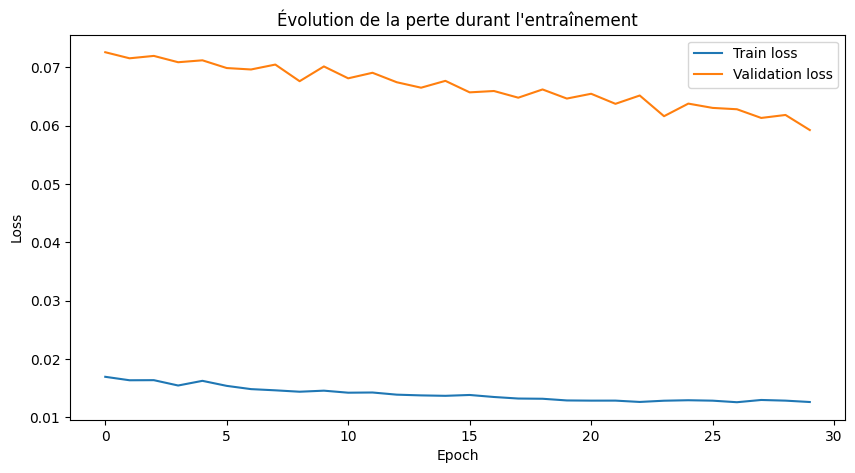

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_denoising.history['loss'],     label='Train loss',      color='steelblue', lw=2)
ax.plot(history_denoising.history['val_loss'], label='Validation loss', color='tomato',    lw=2, ls='--')
ax.set_title("Évolution de la perte (MSE) durant l'entraînement")
ax.set_xlabel('Époque')
ax.set_ylabel('Loss (MSE)')
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

## 5.4. Visualisation de la MAE durant l'entraînement

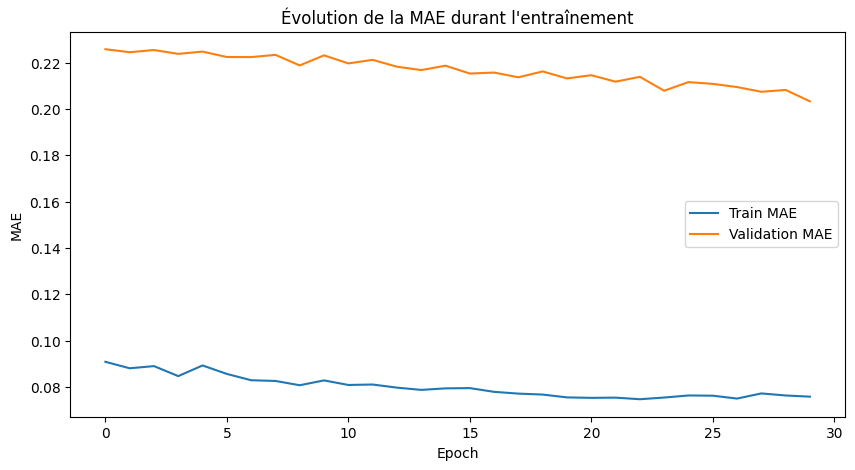

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_denoising.history['mae'],     label='Train MAE',      color='steelblue', lw=2)
ax.plot(history_denoising.history['val_mae'], label='Validation MAE', color='tomato',    lw=2, ls='--')
ax.set_title("Évolution de la MAE durant l'entraînement")
ax.set_xlabel('Époque')
ax.set_ylabel('MAE')
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

# 6. Évaluation du modèle

## 6.1. Évaluation quantitative du modèle sur l'ensemble de test via PSNR

Le **PSNR**, ou Peak Signal-to-Noise Ratio, est une métrique couramment utilisée pour mesurer la qualité d'une image reconstruite par rapport à l'image originale. Il est souvent utilisé dans le contexte de la compression d'images ou de la restauration d'images.

En général, un PSNR plus élevé indique une meilleure qualité. Dans le contexte des images, une valeur de PSNR supérieure à 40 dB est souvent considérée comme une qualité d'image élevée. Une valeur autour de 20-25 dB est considérée comme acceptable. Une valeur en dessous de 20 dB indique généralement une qualité d'image médiocre.

In [ ]:
# Prédiction des images débruitées
decoded_imgs_015 = autoencoder.predict(X_test_015)
decoded_imgs_040 = autoencoder.predict(X_test_040)

print("=" * 72)
print(f"{'Modèle':<30} {'MSE':>8} {'RMSE':>8} {'PSNR(dB)':>10} {'SSIM':>8}")
print("-" * 72)

m_noisy_015 = compute_metrics(y_test_015, X_test_015,       'Bruit seul (0.15)  ')
m_ae_015    = compute_metrics(y_test_015, decoded_imgs_015,  'Auto-encodeur (0.15)')
m_noisy_040 = compute_metrics(y_test_040, X_test_040,       'Bruit seul (0.40)  ')
m_ae_040    = compute_metrics(y_test_040, decoded_imgs_040,  'Auto-encodeur (0.40)')
print("=" * 72)

Les métriques ci-dessus montrent le **PSNR moyen** et le **SSIM** obtenus sur le jeu de test pour les deux niveaux de bruit. La comparaison avec le bruit seul (sans débruitage) permet de quantifier le gain apporté par l'auto-encodeur. Un gain positif en PSNR confirme que le modèle reconstruit mieux que l'image bruitée prise comme référence.

## 6.2. Évaluation quantitative du modèle sur l'ensemble de test via MSE

Le **MSE**, ou Mean Squared Error, est une métrique de performance couramment utilisée pour mesurer l'erreur entre des valeurs prévues et des valeurs réelles. Dans le contexte de la reconstruction d'images (comme avec des auto-encodeurs), il quantifie l'écart entre les images reconstruites et les images originales.

In [ ]:
# MSE déjà calculé via compute_metrics ci-dessus — on affiche juste un rappel
print(f"Auto-encodeur MSE (0.15) : {m_ae_015['mse']:.4f}")
print(f"Auto-encodeur MSE (0.40) : {m_ae_040['mse']:.4f}")

Le MSE et le RMSE quantifient l'écart moyen entre les pixels reconstruits et les pixels originaux sur l'intervalle [0,1]. Des valeurs faibles indiquent une reconstruction fidèle. L'écart entre bruit 0.15 et 0.40 mesure la robustesse du modèle face à un bruitage plus intense.

## 6.3. Visualisation des images débruitées

In [ ]:
n = 6  # nombre d'images à afficher
fig, axes = plt.subplots(5, n, figsize=(n * 3.2, 16))
fig.patch.set_facecolor('white')

row_data = [
    (y_test_015,      'Original',       '#2ecc71'),
    (X_test_015,      'Bruité (0.15)',  '#e74c3c'),
    (X_test_040,      'Bruité (0.40)',  '#c0392b'),
    (decoded_imgs_015,'Débruité (0.15)','#3498db'),
    (decoded_imgs_040,'Débruité (0.40)','#2980b9'),
]

for row_idx, (imgs, title, color) in enumerate(row_data):
    axes[row_idx, 0].set_ylabel(title, fontsize=11, fontweight='bold', color=color,
                                 rotation=90, labelpad=8, va='center')
    for col_idx in range(n):
        ax = axes[row_idx, col_idx]
        ax.imshow(np.clip(imgs[col_idx].astype('float32'), 0, 1), interpolation='lanczos')
        ax.axis('off')
        # Annoter la PSNR sur les images débruitées
        if row_idx == 3:
            p = psnr(y_test_015[col_idx].astype('float32'),
                     decoded_imgs_015[col_idx].astype('float32'), data_range=1.0)
            ax.set_title(f'PSNR {p:.1f} dB', fontsize=8, color='#3498db')
        elif row_idx == 4:
            p = psnr(y_test_040[col_idx].astype('float32'),
                     decoded_imgs_040[col_idx].astype('float32'), data_range=1.0)
            ax.set_title(f'PSNR {p:.1f} dB', fontsize=8, color='#2980b9')

plt.suptitle("Reconstruction par auto-encodeur — Original / Bruité / Débruité",
             fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

On observe que l'image légèrement bruitée a été fidèlement reconstruite étant donné le faible niveau de bruit initial. La différence avant et après reconstruction est moins marquée. Par contre, la reconstruction de l'image fortement bruitée est moins précise, ce qui est attendu étant donné le niveau de bruitage initial assez élevé.

## 6.4. Affinage des images débruitées par masque flou (Unsharp Masking)

L'auto-encodeur produit des images légèrement floues en raison de la nature de la reconstruction convolutive. On applique ici un **masque flou** (*unsharp masking*) sur les images débruitées afin de restituer des détails fins sans dégrader la qualité.

Le principe est simple : on soustrait une version gaussienne floutée de l'image à l'image elle-même, puis on ajoute cette différence pondérée à l'image initiale :

438I_{	ext{net}} = I + lpha \cdot (I - G_{\sigma}(I))438

- **radius = 1.0** : écart-type du filtre gaussien (détails fins)
- **amount = 0.3** : intensité légère pour éviter d'amplifier le bruit résiduel

In [ ]:
from skimage.filters import unsharp_mask

radius = 1.0
amount = 0.35

def safe_float32(arr):
    arr = np.nan_to_num(arr.astype('float64'), nan=0.0, posinf=1.0, neginf=0.0)
    return np.clip(arr, 0.0, 1.0).astype('float32')

def sharpen_images(imgs, radius=1.0, amount=0.35):
    out = []
    for img in imgs:
        img_f = safe_float32(img).astype('float64')
        img_s = unsharp_mask(img_f, radius=radius, amount=amount, channel_axis=-1)
        out.append(safe_float32(img_s))
    return np.array(out)

sharpened_015 = sharpen_images(decoded_imgs_015, radius=radius, amount=amount)
sharpened_040 = sharpen_images(decoded_imgs_040, radius=radius, amount=amount)

y_015_clean = np.array([safe_float32(o) for o in y_test_015])
y_040_clean = np.array([safe_float32(o) for o in y_test_040])

print("=" * 72)
print(f"{'Modèle':<30} {'MSE':>8} {'RMSE':>8} {'PSNR(dB)':>10} {'SSIM':>8}")
print("-" * 72)
m_ae_015_sharp   = compute_metrics(y_015_clean, sharpened_015, 'AE + Défloué (0.15) ')
m_ae_040_sharp   = compute_metrics(y_040_clean, sharpened_040, 'AE + Défloué (0.40) ')
print("=" * 72)

n = 6
row_data = [
    (y_015_clean,      'Original',          '#2ecc71'),
    (X_test_015,       'Bruité (0.15)',     '#e74c3c'),
    (decoded_imgs_015, 'Débruité (0.15)',   '#3498db'),
    (sharpened_015,    'Défloué (0.15)',    '#1abc9c'),
    (decoded_imgs_040, 'Débruité (0.40)',   '#2980b9'),
    (sharpened_040,    'Défloué (0.40)',    '#16a085'),
]
fig, axes = plt.subplots(len(row_data), n, figsize=(n * 3.2, len(row_data) * 3.2))
fig.patch.set_facecolor('white')

for row_idx, (imgs, title, color) in enumerate(row_data):
    axes[row_idx, 0].set_ylabel(title, fontsize=10, fontweight='bold', color=color,
                                 rotation=90, labelpad=8, va='center')
    for col_idx in range(n):
        ax = axes[row_idx, col_idx]
        ax.imshow(np.clip(imgs[col_idx].astype('float32'), 0, 1), interpolation='lanczos')
        ax.axis('off')

plt.suptitle("Original → Bruité → Débruité (AE) → Défloué (Unsharp Mask)",
             fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

# 7. Un second modèle pour comparer

Afin de comparer les performances de l'auto-encodeur de base, un second modèle d'architecture **U-Net** a été intégré (section 4.3). Contrairement à un auto-encodeur classique, le U-Net utilise des **connexions de saut** (*skip connections*) entre l'encodeur et le décodeur, permettant de préserver les détails haute fréquence lors de la reconstruction.

Le U-Net est entraîné avec une **perte combinée pondérée** (0.85 × MSE + 0.15 × (1 - SSIM)) qui intègre directement la perception de la qualité visuelle dans l'optimisation.

Note : Une tentative d'auto-encodeur variationnel (VAE) avait été envisagée mais abandonnée en raison d'erreurs mémoire (*out of memory*) sur les machines du Numérilab.

In [ ]:
# ─── Synthèse finale : tableau comparatif de tous les modèles ───
print('=' * 72)
print('SYNTHÈSE — COMPARAISON DES MODÈLES')
print('=' * 72)
print(f'{"Modèle":<30} {"MSE":>8} {"RMSE":>8} {"PSNR(dB)":>10} {"SSIM":>8}')
print('-' * 72)

# Bruit seul (sans débruitage) comme référence
m_noisy_015 = compute_metrics(y_test_015, X_test_015,        'Bruit seul (0.15)   ')
m_noisy_040 = compute_metrics(y_test_040, X_test_040,        'Bruit seul (0.40)   ')
print('-' * 72)
m_ae_015    = compute_metrics(y_test_015, decoded_imgs_015,   'Auto-enc. (0.15)    ')
m_ae_040    = compute_metrics(y_test_040, decoded_imgs_040,   'Auto-enc. (0.40)    ')
print('-' * 72)
m_ae_s015   = compute_metrics(y_test_015, sharpened_015,      'AE+Défloué (0.15)   ')
m_ae_s040   = compute_metrics(y_test_040, sharpened_040,      'AE+Défloué (0.40)   ')
print('-' * 72)
m_unet_015  = compute_metrics(y_test_015, decoded_unet_015,   'U-Net (0.15)        ')
m_unet_040  = compute_metrics(y_test_040, decoded_unet_040,   'U-Net (0.40)        ')
print('=' * 72)

# ─── Histogramme des PSNR ───
labels   = ['Bruit\n(0.15)', 'AE\n(0.15)', 'AE+Défloué\n(0.15)', 'U-Net\n(0.15)',
            'Bruit\n(0.40)', 'AE\n(0.40)', 'AE+Défloué\n(0.40)', 'U-Net\n(0.40)']
psnr_vals = [m_noisy_015['psnr'], m_ae_015['psnr'], m_ae_s015['psnr'], m_unet_015['psnr'],
             m_noisy_040['psnr'], m_ae_040['psnr'], m_ae_s040['psnr'], m_unet_040['psnr']]
colors = ['#e74c3c','#3498db','#1abc9c','#9b59b6'] * 2

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(labels, psnr_vals, color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, psnr_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('PSNR (dB)', fontweight='bold')
ax.set_title('Comparaison PSNR — tous les modèles (bruit 0.15 et 0.40)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(psnr_vals) * 1.15)
plt.tight_layout()
plt.show()

# ─── Histogramme des SSIM ───
ssim_vals = [m_noisy_015['ssim'], m_ae_015['ssim'], m_ae_s015['ssim'], m_unet_015['ssim'],
             m_noisy_040['ssim'], m_ae_040['ssim'], m_ae_s040['ssim'], m_unet_040['ssim']]
fig2, ax2 = plt.subplots(figsize=(13, 5))
bars2 = ax2.bar(labels, ssim_vals, color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars2, ssim_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylabel('SSIM', fontweight='bold')
ax2.set_title('Comparaison SSIM — tous les modèles (bruit 0.15 et 0.40)', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

# 8. Conclusion

Ce notebook a comparé trois approches de débruitage d'images couleur :

| Modèle | Points forts | Points faibles |
|--------|-------------|----------------|
| **Auto-encodeur convolutif** | Simple, rapide à entraîner | PSNR limité sans skip connections |
| **AE + Unsharp Mask** | Améliore les détails fins sans ré-entraîner | Peut amplifier le bruit résiduel |
| **U-Net** | Skip connections → meilleure préservation des détails | Plus lourd en mémoire |

**Axes d'amélioration :**
- Augmenter la taille du dataset (data augmentation agressive)
- Entraîner davantage d'époques avec un scheduler cosinus
- Utiliser une perte perceptuelle (VGG features) pour améliorer la qualité visuelle
- Tester un modèle DnCNN ou FFDNet optimisé pour les images couleur haute résolution
